In [1]:
## Data Augmentation

# read anitomical MRI/MR thermo

from PIL import Image
from IPython.display import display
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from datetime import datetime
from datetime import datetime, timedelta
import os
import imageio
import shutil
import torch

from torchvision.transforms.functional import InterpolationMode

import glob

# RandomRotation(degrees[, interpolation, ...])
# RandomHorizontalFlip([p])

In [2]:
# example anitomicalMRI and thermo
anatomical = Image.open("E:\\Documents\\MRgLITT\\data\\500J\\original\\anatomicalProbesEye\\LP-0001-01-01-01-S2Cropped.png")
thermo = Image.open("E:\\Documents\MRgLITT\\data\\500J\\original\\temperatureData\\LP-0001-01-01-01-056.S2Cropped.png")

Text(0.5, 1.0, 'Thermo')

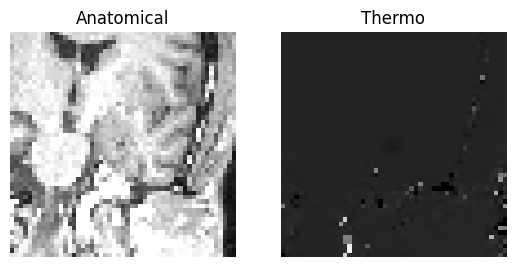

In [56]:
fig, axes = plt.subplots(1, 2)

axes[0].set_axis_off()
axes[0].imshow(anatomical)
axes[0].set_title('Anatomical')

axes[1].set_axis_off()
axes[1].imshow(thermo)
axes[1].set_title('Thermo')


In [175]:
flip = torchvision.transforms.RandomHorizontalFlip()

flipped_anatomical = flip(anatomical)
flipped_thermo = flip(thermo)

Text(0.5, 1.0, 'Thermo')

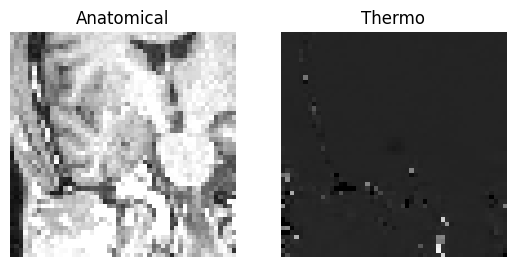

In [176]:
fig, axes = plt.subplots(1, 2)

axes[0].set_axis_off()
axes[0].imshow(flipped_anatomical)
axes[0].set_title('Anatomical')

axes[1].set_axis_off()
axes[1].imshow(flipped_thermo)
axes[1].set_title('Thermo')



Text(0.5, 1.0, 'rot90_thermo')

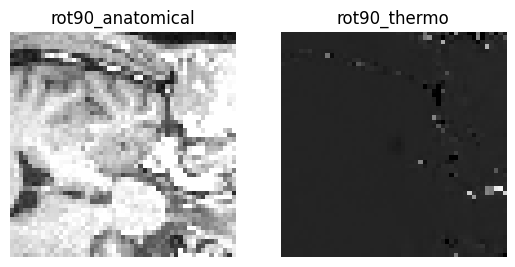

In [181]:
fig, axes = plt.subplots(1, 2)

axes[0].set_axis_off()
axes[0].imshow(rot_anatomical)
axes[0].set_title('rot90_anatomical')

axes[1].set_axis_off()
axes[1].imshow(rot_thermo)
axes[1].set_title('rot90_thermo')

In [16]:
# anatomicalPngs = glob.glob("E:\\Documents\\MRgLITT\\data\\500J\\first_acquisition\\anatomicalProbesEye\\*.png")
# thermoPngs = glob.glob("E:\\Documents\\MRgLITT\\data\\500J\\first_acquisition\\temperatureData\\*.png")
anatomicalPngs = glob.glob("E:\Documents\MRgLITT\data\\500J\segmentation\\three_regions\segmentationData_3Regions_no_t2_1D\\*.png")
thermoPngs = glob.glob("E:\Documents\MRgLITT\data\\500J\segmentation\\temperatureData_no_t2\\*.png")




# test = ['0239-', '0377-', '0092-', '0253-', '0125-', '0332-', '0009-', '0222-', '0343-', '0188-', '0032-', '0568-', '0349-', '0186-', '0200-', '0372-']
# train_valid = ['0101-', '0337-', '0615-', '0002-', '0560-', '0285-', '0075-', '0518-', '0076-', '0080-', '0201-', '0231-', '0135-', '0368-', '0130-', '0008-', '0501-', '0003-', '0033-', '0150-', '0085-', '0192-', '0097-', '0006-', '0007-', '0367-', '0576-', '0010-', '0265-', '0084-', '0504-', '0344-', '0011-', '0238-', '0001-', '0257-', '0613-', '0152-', '0614-', '0998-', '0104-', '0136-', '0203-', '0193-', '0216-', '0023-', '0621-', '0535-', '0455-', '0117-', '0112-', '0561-', '0633-', '0005-', '0317-', '0022-', '0559-', '0025-', '0041-', '0113-', '0128-', '0137-', '0004-', '0026-']
train_valid =  ['0097-', '0084-', '0455-', '0112-', '0285-', '0265-', '0561-', '0092-', '0104-', '0025-', '0222-', '0253-', '0372-', '0621-', '0231-', '0113-', '0559-', '0005-', '0200-', '0101-', '0377-', '0023-', '0001-', '0076-', '0135-', '0518-', '0128-', '0504-', '0238-', '0026-', '0615-', '0368-', '0203-', '0186-', '0613-', '0032-', '0501-', '0002-', '0003-', '0130-', '0201-', '0006-', '0192-', '0560-', '0257-', '0007-', '0332-', '0011-', '0633-', '0041-', '0193-', '0004-', '0033-']

import re

listt = []

# Define augmentation
horizontal_flip = torchvision.transforms.RandomHorizontalFlip(p=100)

# ANATOMICAL PNGS
for file_path in anatomicalPngs:
    for pattern in train_valid:
        match = re.search(pattern, file_path)

        AugmentedAnatomicalPath = file_path.replace('segmentationData_1D', 'segmentationData_1D_Augmented')

        # If file is in training/validation data, augment and save
        if match:

            # Convert pngs to PIL and flip
            anatomicalPIL = Image.open(file_path)
            horFlip_anatomical = horizontal_flip(anatomicalPIL)

            # Save augmented training data
            FlippedImagePath = AugmentedAnatomicalPath + "-Flip.png"
            horFlip_anatomical.save(FlippedImagePath)

            # Copy original training images to new augmented
            # print(file_path, AugmentedAnatomicalPath)
            shutil.copyfile(file_path, AugmentedAnatomicalPath)

            # print(file_path)
            # listt.append(file_path)

        # If file is testing data
        else:
            # Copy original testing images to new augmented
            # print(file_path, AugmentedAnatomicalPath)
            shutil.copyfile(file_path, AugmentedAnatomicalPath)
        


# THEROM PNGS
for file_path in thermoPngs:
    for pattern in train_valid:
        match = re.search(pattern, file_path)

        AugmentedThermoPath = file_path.replace('temperatureData_no_t2', 'temperatureData_no_t2_Augmented')

        # If file is in training/validation data, augment and save
        if match:

            # Convert pngs to PIL and flip
            thermoPIL = Image.open(file_path)
            horFlip_Thermo = horizontal_flip(thermoPIL)

            # Save augmented training data
            FlippedImagePath = AugmentedThermoPath + "-Flip.png"
            horFlip_Thermo.save(FlippedImagePath)

            # Copy original training images to new augmented
            # print(file_path, AugmentedThermoPath)
            shutil.copyfile(file_path, AugmentedThermoPath)

            # print(file_path)
            # listt.append(file_path)

        # If file is testing data
        else:
            # print(file_path, AugmentedThermoPath)
            # Copy original testing images to new augmented
            shutil.copyfile(file_path, AugmentedThermoPath)







SameFileError: 'E:\\Documents\\MRgLITT\\data\\500J\\segmentation\\three_regions\\segmentationData_3Regions_no_t2_1D\\LP-0001-01-01-01-S2Cropped.png' and 'E:\\Documents\\MRgLITT\\data\\500J\\segmentation\\three_regions\\segmentationData_3Regions_no_t2_1D\\LP-0001-01-01-01-S2Cropped.png' are the same file

In [211]:
# def all(anatomicalPngPath, all_pngs):
    
#     base_path = "E:\\Documents\\MRgLITT\\data\\500J\\original_horizontal\\"

#     for path in 

In [212]:

# def generate_folder_paths_anatomical(list_sub_folder_names,train_id_list):
#     folder_paths = []
#     base_path = "E:\\Documents\\MRgLITT\\data\\500J\\horizontalFlip\\"


#     for sub_folder_name in list_sub_folder_names:
        

#         if sub_folder_name[3:8] not in train_id_list:
#             folder_path = os.path.join(base_path, "anatomicalProbesEye", sub_folder_name + "-Flip.png")
#             folder_paths.append(folder_path)
#             os.makedirs(os.path.dirname(folder_path), exist_ok=True)

#     return folder_paths


# def generate_folder_paths_thermo(list_sub_folder_names,train_id_list):
#     folder_paths = []
#     base_path = "E:\\Documents\\MRgLITT\\data\\500J\\horizontalFlip" ## Change depending on augmentation

#     for sub_folder_name in list_sub_folder_names:

#         if sub_folder_name[3:8] not in train_id_list:
#             folder_path = os.path.join(base_path, "temperatureData", sub_folder_name + "-Flip.png")
#             folder_paths.append(folder_path)
#             os.makedirs(os.path.dirname(folder_path), exist_ok=True)

#     return folder_paths

# test = ['0239-', '0377-', '0092-', '0253-', '0125-', '0332-', '0009-', '0222-', '0343-', '0188-', '0032-', '0568-', '0349-', '0186-', '0200-', '0372-']
# anatomicalProbesEyeFlippedPath = generate_folder_paths_anatomical(all_pngs,test)
# thermoFlippedPath = generate_folder_paths_thermo(all_thermos,test)

In [255]:
# # Define type of augmentation (pytorch library)
# horizontal_flip = torchvision.transforms.RandomHorizontalFlip()

# for anatomicalPath, thermoPath in zip(anatomicalProbesEyeFlippedPath,thermoFlippedPath):

#     anatomicalOG = anatomicalPath[:-9] + anatomicalPath[-4:]
#     thermoOG = thermoPath[:-9] + thermoPath[-4:]
#     anatomicalOG = anatomicalOG.replace('horizontalFlip', 'original')
#     thermoOG = thermoOG.replace('horizontalFlip', 'original')

#     # Convert pngs to PIL and flip
#     anatomicalPIL = Image.open(anatomicalOG)
#     horFlip_anatomical = horizontal_flip(anatomicalPIL)

#     thermoPIL = Image.open(thermoOG)
#     horFlip_thermo = horizontal_flip(thermoPIL)

#     # Save augmented images in new directory
#     NewAnatomicalPath = anatomicalOG.replace('original', 'original_horizontal')
#     NewThermoPath = thermoOG.replace('original', 'original_horizontal')
#     print(NewAnatomicalPath)
#     print(NewThermoPath)
#     horFlip_anatomical.save(anatomicalPath)
#     horFlip_thermo.save(thermoPath)

In [216]:
# # Define type of augmentaiton
# degrees = [90,90]
# LeftRotation = torchvision.transforms.RandomRotation(degrees, interpolation=InterpolationMode.NEAREST, expand=False, center=None, fill=0)

# for i in range(len(anatomicalProbesEyeFlippedPath)):

#     # Convert pngs to PIL and rotate
#     anatomicalPIL = Image.open(anatomicalPngs[i])
#     leftRot_anatomical = LeftRotation(anatomicalPIL)

#     thermoPIL = Image.open(thermoPngs[i])
#     leftRot_thermo = LeftRotation(thermoPIL)

#     # Save images in new directory
#     leftRot_anatomical.save(anatomicalProbesEyeFlippedPath[i])
#     leftRot_thermo.save(thermoFlippedPath[i])

In [217]:
"E:\Documents\MRgLITT\data\500J\horizontalFlip\anatomicalProbesEye\LP-0001-01-01-01.png"

'E:\\Documents\\MRgLITT\\dataŀJ\\horizontalFlip\x07natomicalProbesEye\\LP-0001-01-01-01.png'

In [151]:
# path = "E:\\Documents\\MRgLITT\\data\\500J\\original_horizontal\\anatomicalProbesEye"

# # Iterate over the contents of the folder
# for filename in os.listdir(path):
#     file_path = os.path.join(path, filename)

#     if os.path.isfile(file_path):
#         # Delete the file
#         os.remove(file_path)

# for i in range(len(anatomicalProbesEyeFlippedPath)):
#     original1 = anatomicalProbesEyeFlippedPath[i]# augmented
#     target1 = 'E:\\Documents\\MRgLITT\\data\\500J\\original_horizontal\\anatomicalProbesEye\\'+str(anatomicalPngs[i][-30:-4])+"-Flip.png"
#     shutil.copyfile(original1, target1)

    
# for i in range(len(anatomicalPngs)):
#     original2 = anatomicalPngs[i]# original
#     target2 = 'E:\\Documents\\MRgLITT\\data\\500J\\original_horizontal\\anatomicalProbesEye\\'+str(anatomicalPngs[i][-30:-4])+".png"
#     shutil.copyfile(original2, target2)



In [152]:
# path = "E:\\Documents\\MRgLITT\\data\\500J\\original_horizontal\\temperatureData"

# # Iterate over the contents of the folder
# for filename in os.listdir(path):
#     file_path = os.path.join(path, filename)

#     if os.path.isfile(file_path):
#         # Delete the file
#         os.remove(file_path)

# for i in range(len(thermoFlippedPath)):
#     original1 = thermoFlippedPath[i]# augmented
#     target1 = 'E:\\Documents\\MRgLITT\\data\\500J\\original_horizontal\\temperatureData\\'+str(thermoPngs[i][-34:-4])+"-Flip.png"    
#     shutil.copyfile(original1, target1)
#     # print(target1)


# for i in range(len(thermoPngs)):
#     original2 = thermoPngs[i]# original
#     target2 = 'E:\\Documents\\MRgLITT\\data\\500J\\original_horizontal\\temperatureData\\'+str(thermoPngs[i][-34:-4])+".png"
#     shutil.copyfile(original2, target2)

#     # print(target2)

In [116]:
# thermoPngs[i][-34:-4]

'LP-0621-01-01-03-056.S2Cropped'